# Project 1 - Social Media Sentiment and Engagement Analysis
### Codveda Business Analytics Internship

**Source dataset:** `3) Sentiment dataset.csv` from the supplied internship dataset package. The project copy may be saved as `sentiment_dataset_raw.csv`.

**Tools used:** Python with pandas, numpy, matplotlib, scipy and scikit-learn in Jupyter Notebook.

This notebook focuses on exploratory business analytics: data quality checks, cleaning, descriptive statistics, sentiment and platform analysis, country and time trends, correlation, regression and basic statistical testing. All reported values come from the supplied dataset.

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (9,5)
plt.rcParams['font.size'] = 10

pd.set_option('display.max_columns', 50)
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Dataset Understanding and Data Dictionary

We load the raw dataset exactly as supplied and inspect its real shape, column names, and data types
before making any changes.

In [2]:
df = pd.read_csv("../01_Datasets/sentiment_dataset_raw.csv")
print("Shape (rows, columns):", df.shape)
df.head()


Shape (rows, columns): (732, 15)


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    str    
 3   Sentiment     732 non-null    str    
 4   Timestamp     732 non-null    str    
 5   User          732 non-null    str    
 6   Platform      732 non-null    str    
 7   Hashtags      732 non-null    str    
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    str    
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), str(7)
memory usage: 85.9 KB


**Data Dictionary**

| Column | Type | Description |
|---|---|---|
| Text | string | Raw social media post content |
| Sentiment | string | Raw fine-grained emotion label assigned to the post |
| Timestamp | string/datetime | Date & time the post was published |
| User | string | Username/handle of the poster |
| Platform | string (category) | Instagram, Twitter, or Facebook |
| Hashtags | string | Hashtags attached to the post |
| Retweets | float | Number of retweets/reshares |
| Likes | float | Number of likes |
| Country | string (category) | Country associated with the post |
| Year, Month, Day, Hour | int | Extracted from Timestamp |

Two columns, `Unnamed: 0.1` and `Unnamed: 0`, are leftover pandas export index columns and are not real
variables - they are dropped in the cleaning step below.

## 3. Data Quality Assessment

In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())
print("\nFully duplicated rows:", df.duplicated().sum())
print("\nNumber of distinct raw Sentiment labels:", df['Sentiment'].str.strip().nunique())


Missing values per column:
Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

Total missing values: 0

Fully duplicated rows: 0

Number of distinct raw Sentiment labels: 191


**Data quality result:** the dataset contains **0 missing values** and **0 fully duplicated rows** across 732 records. Before whitespace cleaning, the Sentiment column contains **279 distinct stored strings**. After trimming leading and trailing spaces, these reduce to **191 unique normalized labels**. The normalized labels are grouped into Positive, Negative and Neutral in the cleaning step.

## 4. Data Cleaning

Steps performed:
1. Drop the two redundant index columns (`Unnamed: 0.1`, `Unnamed: 0`).
2. Strip leading and trailing whitespace from text columns.
3. Group the normalized sentiment labels into **Positive, Negative and Neutral** using a documented keyword rule plus manual review of labels that were not captured by the keyword lists.
4. Check the engagement variables for potential outliers using the IQR rule.

The sentiment grouping is an analytical classification used for this project; the original Sentiment column is kept in the cleaned dataset.

In [5]:
df_clean = df.drop(columns=['Unnamed: 0.1','Unnamed: 0']).copy()

for c in df_clean.columns:
    if df_clean[c].dtype == object or str(df_clean[c].dtype) in ('object','str'):
        df_clean[c] = df_clean[c].apply(lambda x: str(x).strip() if pd.notna(x) else x)

print("Cleaned shape:", df_clean.shape)
df_clean.head()


Cleaned shape: (732, 13)


,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [6]:
positive_kw = ['positive','joy','excitement','contentment','gratitude','happy','hopeful','serenity',
'pride','admiration','love','amusement','elation','enthusiasm','optimism','delight','wonder',
'awe','inspired','inspiration','confidence','satisfaction','triumph','curiosity','playful',
'kind','freedom','blessed','thrill','relief','grateful','proud','joyful','excited','positivity',
'motivation','determination','empowerment','accomplishment','affection','harmony','euphoria',
'radiance','elegance','festivejoy','adventure','creativity','iconic','charm','enchantment',
'success','vibrancy','celebration','ecstasy','yearning','enjoyment','arousal','challenge']

negative_kw = ['negative','sad','despair','grief','loneliness','confusion','embarrass','fear',
'anger','disgust','anxiety','frustrat','regret','hate','jealous','disappoint','bitter',
'heartbreak','betrayal','suffering','pain','melancholy','isolation','sorrow','envy',
'devastated','loss','hopeless','desolation','darkness','ruins','exhaustion','numbness',
'helplessness','miscalculation','overwhelmed','obstacle','pressure','shame','resentment']

# Manual review of the remaining ambiguous / rare labels (documented judgment call)
manual_map = {
'Nostalgia':'Neutral','Acceptance':'Positive','Surprise':'Neutral','Indifference':'Neutral',
'Ambivalence':'Neutral','Bad':'Negative','Happiness':'Positive','Hope':'Positive','Calmness':'Positive',
'Compassion':'Positive','Tenderness':'Positive','Fulfillment':'Positive','Reverence':'Positive',
'Boredom':'Negative','Compassionate':'Positive','Reflection':'Neutral','Anticipation':'Positive',
'Empathetic':'Positive','Free-spirited':'Positive','Confident':'Positive','Envious':'Negative',
'Dismissive':'Negative','Adoration':'Positive','Intimidation':'Negative','Zest':'Positive',
'Apprehensive':'Negative','Contemplation':'Neutral','Whimsy':'Positive','Rejuvenation':'Positive',
'Coziness':'Positive','Resilience':'Positive','Exploration':'Positive','Captivation':'Positive',
'Tranquility':'Positive','Emotion':'Neutral','Mischievous':'Positive','Appreciation':'Positive',
'Intrigue':'Neutral','Mindfulness':'Positive','DreamChaser':'Positive','Pensive':'Neutral',
'Melodic':'Positive','InnerJourney':'Neutral','Dazzle':'Positive','Adrenaline':'Positive',
'ArtisticBurst':'Positive','CulinaryOdyssey':'Positive','Immersion':'Positive','Spark':'Positive',
'Marvel':'Positive','EmotionalStorm':'Negative','Desperation':'Negative','Heartache':'Negative',
'Solitude':'Negative','Friendship':'Positive','Amazement':'Positive','Romance':'Positive',
'Grandeur':'Positive','Energy':'Positive','Colorful':'Positive','Hypnotic':'Neutral',
'Connection':'Positive','Journey':'Neutral','Engagement':'Positive','Touched':'Positive',
'Suspense':'Negative','Heartwarming':'Positive','Sympathy':'Neutral','Renewed Effort':'Positive',
'Solace':'Positive','Breakthrough':'Positive','Envisioning History':'Neutral','Imagination':'Positive',
'Mesmerizing':'Positive','Winter Magic':'Positive',"Nature's Beauty":'Positive',
'Whispers of the Past':'Neutral',
}

def classify(label):
    if label in manual_map:
        return manual_map[label]
    l = label.lower()
    if 'neutral' in l:
        return 'Neutral'
    for kw in positive_kw:
        if kw in l:
            return 'Positive'
    for kw in negative_kw:
        if kw in l:
            return 'Negative'
    return 'Unclassified'

df_clean['Sentiment_Group'] = df_clean['Sentiment'].apply(classify)
print("Unclassified remaining:", (df_clean['Sentiment_Group']=='Unclassified').sum())
print()
print(df_clean['Sentiment_Group'].value_counts())
print()
print((df_clean['Sentiment_Group'].value_counts(normalize=True)*100).round(2))


Unclassified remaining: 0

Sentiment_Group
Positive    474
Negative    195
Neutral      63
Name: count, dtype: int64

Sentiment_Group
Positive    64.75
Negative    26.64
Neutral      8.61
Name: proportion, dtype: float64


In [7]:
# Outlier check on numeric engagement columns using IQR method
for col in ['Likes','Retweets']:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f"{col}: IQR bounds = [{lower:.2f}, {upper:.2f}], outliers found = {len(outliers)}")


Likes: IQR bounds = [11.88, 72.88], outliers found = 18
Retweets: IQR bounds = [6.88, 35.88], outliers found = 18


**Outlier check:** the IQR rule flags **18 Likes values** and **18 Retweets values** as potential outliers. These observations are still within the valid observed ranges (Likes 10 to 80; Retweets 5 to 40), and there is no evidence that they are data-entry errors. They are therefore retained in the analysis rather than removed automatically.

## 5. Descriptive Statistics - Likes and Retweets

In [8]:
desc = df_clean[['Likes','Retweets']].agg(['count','mean','median','std','var','min','max'])
mode_vals = df_clean[['Likes','Retweets']].mode().iloc[0]
desc.loc['mode'] = mode_vals
desc


,Likes,Retweets
count,732.000000,732.000000
mean,42.901639,21.508197
median,43.000000,22.000000
std,14.089848,7.061286
var,198.523828,49.861766
min,10.000000,5.000000
max,80.000000,40.000000
mode,45.000000,22.000000


**Descriptive statistics:**
- Likes: mean 42.90, median 43, mode 45, standard deviation 14.09
- Retweets: mean 21.51, median 22, mode 22, standard deviation 7.06

These values are consistent with the companion Excel analysis. They provide a simple baseline for typical engagement in the supplied records.

## 6. Exploratory Data Analysis
### 6.1 Sentiment Distribution

Sentiment_Group
Positive    474
Negative    195
Neutral      63
Name: count, dtype: int64

Sentiment_Group
Positive    64.75
Negative    26.64
Neutral      8.61
Name: count, dtype: float64


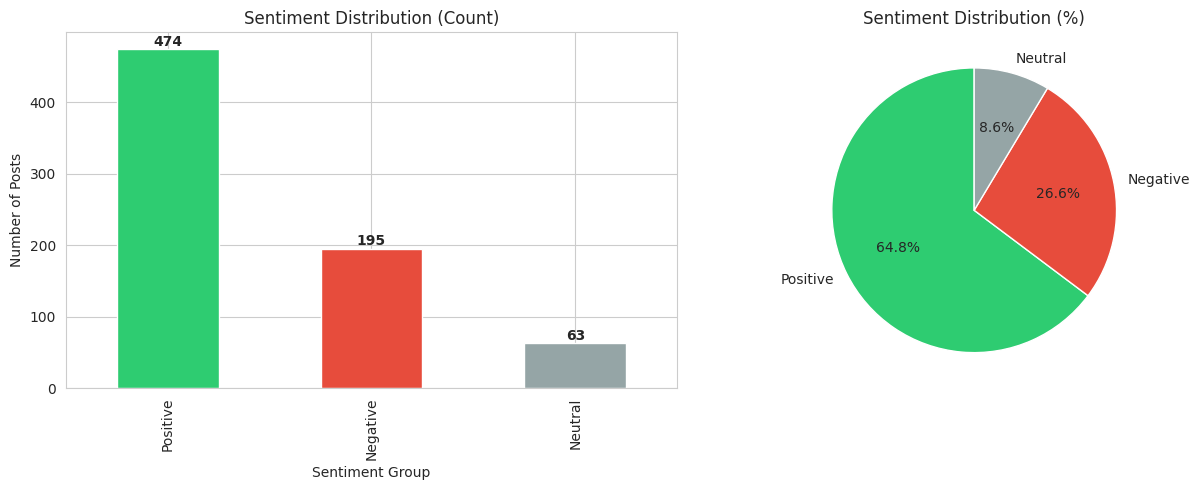

In [9]:
sentiment_counts = df_clean['Sentiment_Group'].value_counts()
sentiment_pct = (sentiment_counts / len(df_clean) * 100).round(2)
print(sentiment_counts)
print()
print(sentiment_pct)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
colors = {'Positive':'#2ecc71','Negative':'#e74c3c','Neutral':'#95a5a6'}
sentiment_counts.plot(kind='bar', ax=axes[0], color=[colors[i] for i in sentiment_counts.index])
axes[0].set_title('Sentiment Distribution (Count)')
axes[0].set_ylabel('Number of Posts')
axes[0].set_xlabel('Sentiment Group')
for i, v in enumerate(sentiment_counts):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')

axes[1].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
            colors=[colors[i] for i in sentiment_counts.index], startangle=90)
axes[1].set_title('Sentiment Distribution (%)')
plt.tight_layout()
plt.savefig('../06_Reports/charts_project1/sentiment_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


**Result:** Positive sentiment accounts for **64.75%** of records (474 posts), Negative for **26.64%** (195 posts), and Neutral for **8.61%** (63 posts).

### 6.2 Platform Analysis

In [10]:
platform_summary = df_clean.groupby('Platform').agg(
    Post_Count=('Platform','count'),
    Avg_Likes=('Likes','mean'),
    Avg_Retweets=('Retweets','mean')
).round(2).sort_values('Post_Count', ascending=False)
platform_summary['Pct_of_Posts'] = (platform_summary['Post_Count']/len(df_clean)*100).round(2)
platform_summary


,Post_Count,Avg_Likes,Avg_Retweets,Pct_of_Posts
Platform,,,,
Instagram,258,45.09,22.60,35.25
Twitter,243,41.56,20.86,33.20
Facebook,231,41.87,20.97,31.56


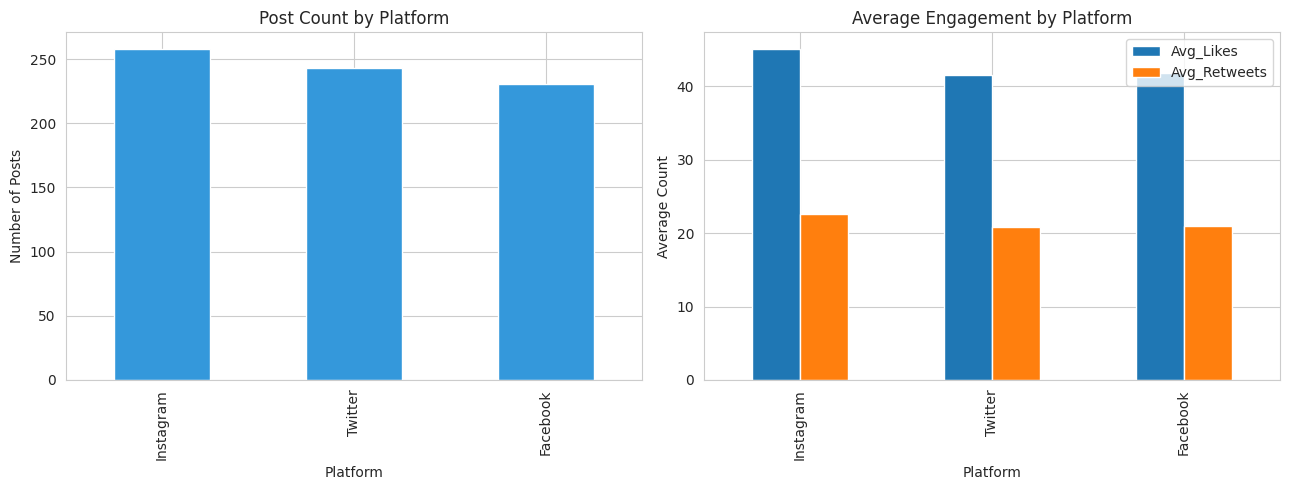

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
platform_summary['Post_Count'].plot(kind='bar', ax=axes[0], color='#3498db')
axes[0].set_title('Post Count by Platform')
axes[0].set_ylabel('Number of Posts')

platform_summary[['Avg_Likes','Avg_Retweets']].plot(kind='bar', ax=axes[1])
axes[1].set_title('Average Engagement by Platform')
axes[1].set_ylabel('Average Count')
plt.tight_layout()
plt.savefig('../06_Reports/charts_project1/platform_analysis.png', dpi=120, bbox_inches='tight')
plt.show()


**Result:** Instagram has 258 posts (35.25%), Twitter 243 (33.20%), and Facebook 231 (31.56%). Instagram also has the highest average Likes (45.09) and average Retweets (22.60) in this dataset.

### 6.3 Likes and Retweets (Engagement) Distributions

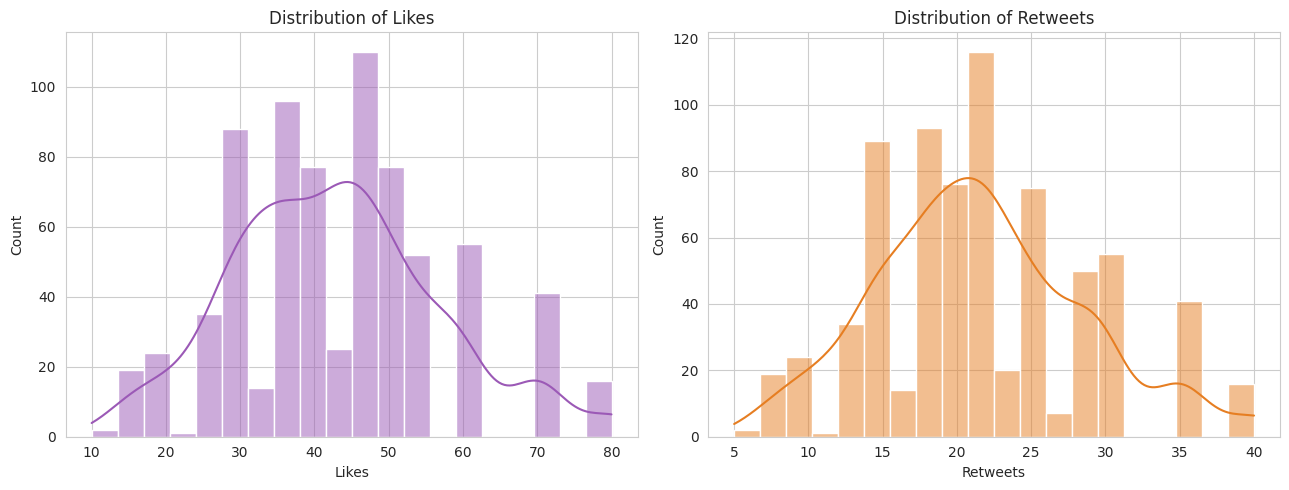

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.histplot(df_clean['Likes'], bins=20, kde=True, ax=axes[0], color='#9b59b6')
axes[0].set_title('Distribution of Likes')
sns.histplot(df_clean['Retweets'], bins=20, kde=True, ax=axes[1], color='#e67e22')
axes[1].set_title('Distribution of Retweets')
plt.tight_layout()
plt.savefig('../06_Reports/charts_project1/engagement_distributions.png', dpi=120, bbox_inches='tight')
plt.show()


### 6.4 Country Analysis

In [13]:
country_summary = df_clean.groupby('Country').agg(
    Post_Count=('Country','count'),
    Avg_Likes=('Likes','mean'),
    Avg_Retweets=('Retweets','mean')
).round(2).sort_values('Post_Count', ascending=False)
print("Total distinct countries:", df_clean['Country'].nunique())
country_summary.head(10)


Total distinct countries: 33


,Post_Count,Avg_Likes,Avg_Retweets
Country,,,
USA,188,44.46,22.31
UK,143,40.75,20.50
Canada,135,40.65,20.38
Australia,75,39.01,19.52
India,70,38.21,19.06
Brazil,17,52.94,26.35
France,16,46.25,23.25
Japan,15,52.33,26.20
Germany,14,48.21,24.21


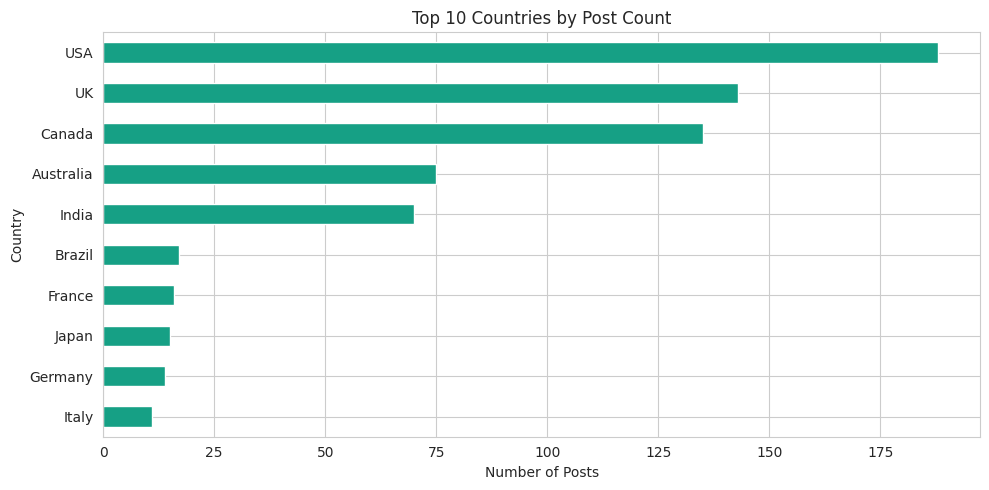

In [14]:
top10 = country_summary.head(10)
fig, ax = plt.subplots(figsize=(10,5))
top10['Post_Count'].plot(kind='barh', ax=ax, color='#16a085')
ax.invert_yaxis()
ax.set_title('Top 10 Countries by Post Count')
ax.set_xlabel('Number of Posts')
plt.tight_layout()
plt.savefig('../06_Reports/charts_project1/country_analysis.png', dpi=120, bbox_inches='tight')
plt.show()


**Result:** the dataset contains **33 countries**. The five largest groups are USA (188), UK (143), Canada (135), Australia (75), and India (70), together representing more than 83% of the records.

### 6.5 Time / Trend Analysis

In [15]:
year_summary = df_clean.groupby('Year').agg(
    Post_Count=('Year','count'),
    Avg_Likes=('Likes','mean'),
    Avg_Retweets=('Retweets','mean')
).round(2)
year_summary


,Post_Count,Avg_Likes,Avg_Retweets
Year,,,
2010,3,53.33,26.67
2011,4,46.25,22.75
2012,4,40.00,20.00
2013,4,43.75,22.00
2014,4,40.00,20.00
2015,19,45.21,22.84
2016,38,43.71,22.00
2017,43,41.51,20.74
2018,56,44.73,22.38


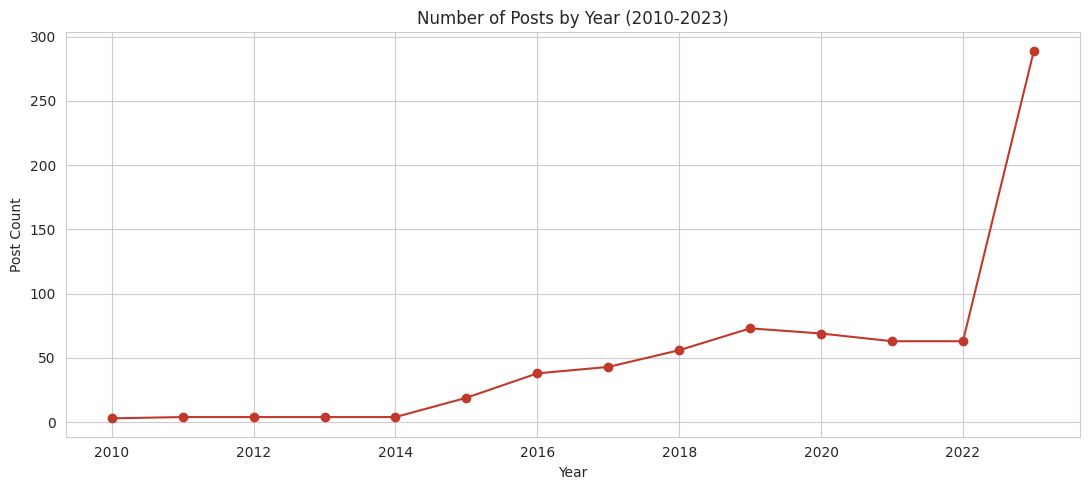

In [16]:
fig, ax = plt.subplots(figsize=(11,5))
year_summary['Post_Count'].plot(kind='line', marker='o', ax=ax, color='#c0392b')
ax.set_title('Number of Posts by Year (2010-2023)')
ax.set_xlabel('Year')
ax.set_ylabel('Post Count')
plt.tight_layout()
plt.savefig('../06_Reports/charts_project1/time_trend.png', dpi=120, bbox_inches='tight')
plt.show()


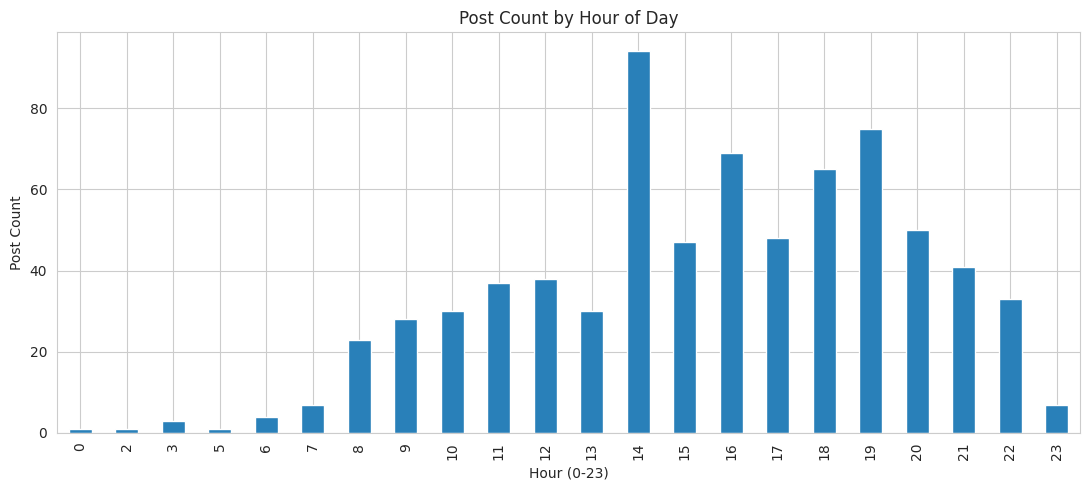

Peak posting hour: 14 with 94 posts


In [17]:
hour_summary = df_clean.groupby('Hour').size()
fig, ax = plt.subplots(figsize=(11,5))
hour_summary.plot(kind='bar', ax=ax, color='#2980b9')
ax.set_title('Post Count by Hour of Day')
ax.set_xlabel('Hour (0-23)')
ax.set_ylabel('Post Count')
plt.tight_layout()
plt.savefig('../06_Reports/charts_project1/hourly_trend.png', dpi=120, bbox_inches='tight')
plt.show()
print("Peak posting hour:", hour_summary.idxmax(), "with", hour_summary.max(), "posts")


## 7. Correlation Analysis

In [18]:
corr_matrix = df_clean[['Likes','Retweets']].corr()
corr_matrix


,Likes,Retweets
Likes,1.000000,0.998482
Retweets,0.998482,1.000000


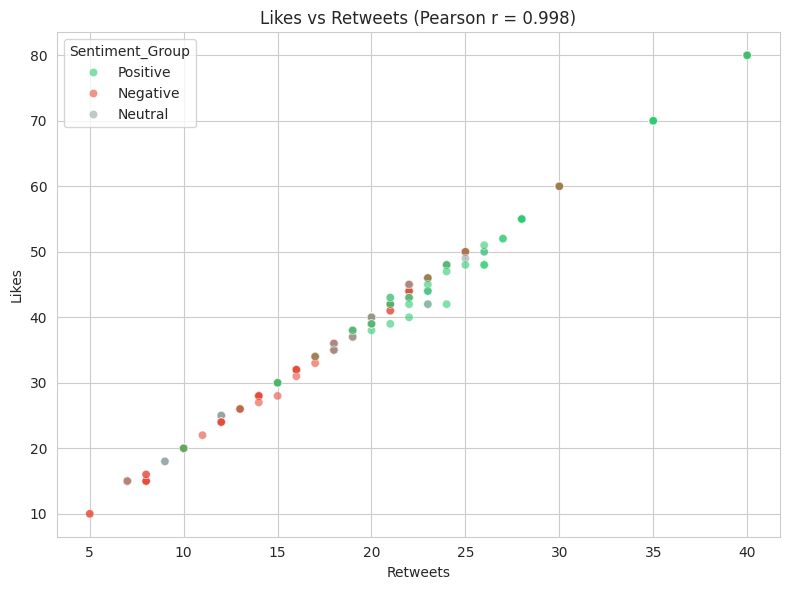

In [19]:
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df_clean, x='Retweets', y='Likes', hue='Sentiment_Group',
                 palette={'Positive':'#2ecc71','Negative':'#e74c3c','Neutral':'#95a5a6'}, alpha=0.6, ax=ax)
ax.set_title(f'Likes vs Retweets (Pearson r = {corr_matrix.loc["Likes","Retweets"]:.3f})')
plt.tight_layout()
plt.savefig('../06_Reports/charts_project1/correlation_scatter.png', dpi=120, bbox_inches='tight')
plt.show()


**Correlation result:** Likes and Retweets have a Pearson correlation of **r = 0.998**. This is an unusually strong relationship, so it should be interpreted as a characteristic of this supplied dataset rather than assumed to be a general rule for live social media data.

## 8. Regression Analysis - Predicting Likes from Retweets

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

X = df_clean[['Retweets']].values
y = df_clean['Likes'].values

reg = LinearRegression()
reg.fit(X, y)
y_pred = reg.predict(X)

print(f"Slope (coefficient): {reg.coef_[0]:.4f}")
print(f"Intercept: {reg.intercept_:.4f}")
print(f"R-squared: {r2_score(y, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y, y_pred):.4f}")


Slope (coefficient): 1.9923
Intercept: 0.0501
R-squared: 0.9970
Mean Absolute Error: 0.5173


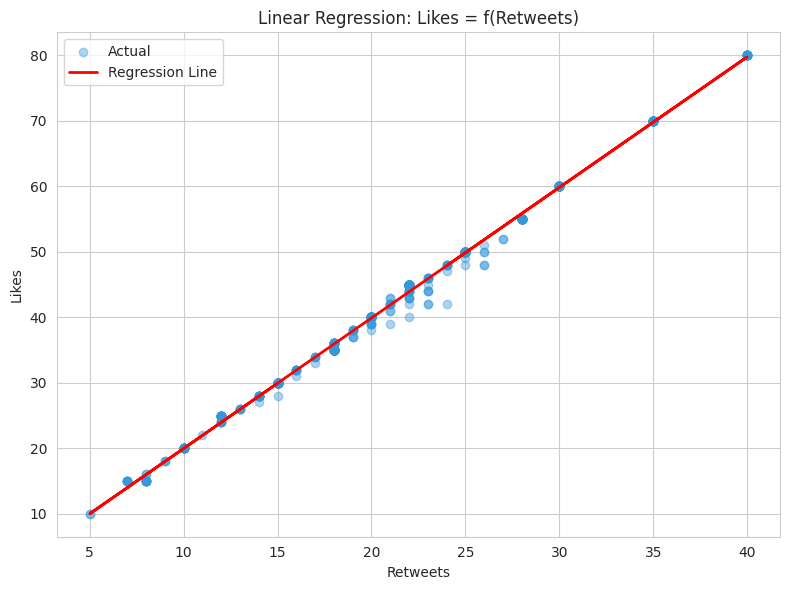

In [21]:
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(df_clean['Retweets'], df_clean['Likes'], alpha=0.4, color='#3498db', label='Actual')
ax.plot(df_clean['Retweets'], y_pred, color='red', linewidth=2, label='Regression Line')
ax.set_xlabel('Retweets')
ax.set_ylabel('Likes')
ax.set_title('Linear Regression: Likes = f(Retweets)')
ax.legend()
plt.tight_layout()
plt.savefig('../06_Reports/charts_project1/regression_line.png', dpi=120, bbox_inches='tight')
plt.show()


**Regression result:** the fitted model is approximately `Likes = 1.992 x Retweets + 0.050`, with `R-squared = 0.997`. In this dataset, Retweets explain almost all of the observed variation in Likes. Because the relationship is unusually strong, it should be validated on another dataset before being used for operational forecasting.

## 9. Statistical Testing

We test whether average Likes differ significantly across Platforms using a one-way ANOVA, and
whether average Likes differ significantly between Positive and Negative sentiment posts using an
independent-samples t-test.

In [22]:
groups = [df_clean[df_clean['Platform']==p]['Likes'] for p in df_clean['Platform'].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"ANOVA - Likes across Platforms: F = {f_stat:.4f}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("Result: statistically significant difference in average Likes across platforms (p < 0.05)")
else:
    print("Result: no statistically significant difference in average Likes across platforms (p >= 0.05)")


ANOVA — Likes across Platforms: F = 4.8819, p-value = 0.0078
Result: statistically significant difference in average Likes across platforms (p < 0.05)


In [23]:
pos_likes = df_clean[df_clean['Sentiment_Group']=='Positive']['Likes']
neg_likes = df_clean[df_clean['Sentiment_Group']=='Negative']['Likes']
t_stat, p_val_t = stats.ttest_ind(pos_likes, neg_likes, equal_var=False)
print(f"T-test - Positive vs Negative Likes: t = {t_stat:.4f}, p-value = {p_val_t:.6f}")
print(f"Mean Likes (Positive): {pos_likes.mean():.2f}   Mean Likes (Negative): {neg_likes.mean():.2f}")
if p_val_t < 0.05:
    print("Result: statistically significant difference - Positive-sentiment posts get significantly different average Likes than Negative-sentiment posts (p < 0.05)")
else:
    print("Result: no statistically significant difference (p >= 0.05)")


T-test — Positive vs Negative Likes: t = 8.6011, p-value = 0.000000
Mean Likes (Positive): 45.97   Mean Likes (Negative): 35.97
Result: statistically significant difference — Positive-sentiment posts get significantly different average Likes than Negative-sentiment posts (p < 0.05)


**Statistical testing results:**
- One-way ANOVA for Likes across platforms: F = 4.8819, p = 0.0078. The average Likes are not equal across all three platforms at the 5% significance level.
- Welch independent-samples t-test for Positive versus Negative Likes: t = 8.6011, p < 0.000001. Positive posts average 45.97 Likes compared with 35.97 for Negative posts.

These tests show statistical association in this sample. They do not establish that platform or sentiment causes the engagement difference.

## 10. Export Cleaned Data for MySQL and Power BI

The cleaned dataset, including `Sentiment_Group`, is exported for the SQL analysis and Power BI dashboard so that the main figures remain consistent across project deliverables.

In [24]:
df_clean.to_csv('../01_Datasets/sentiment_dataset_cleaned.csv', index=False)
print("Exported cleaned dataset:", df_clean.shape)


Exported cleaned dataset: (732, 14)


## 11. Key Business Findings

1. Positive sentiment is the largest group: 474 of 732 posts (64.75%).
2. Platform volume is fairly balanced, with Instagram slightly ahead at 258 posts.
3. Average engagement is 42.90 Likes and 21.51 Retweets per post.
4. Likes and Retweets are very strongly correlated (r = 0.998); this should be validated before generalizing beyond this dataset.
5. The five largest country groups account for more than 83% of the records.
6. The data cover 2010 to 2023, and Hour 14 is the most frequent posting hour with 94 posts.
7. The ANOVA and t-test results indicate statistically significant differences in average Likes by platform and between Positive and Negative sentiment groups.

## 12. Business Recommendations

- Review the Negative-sentiment segment to identify repeated themes that may need attention.
- Give Instagram slightly more attention because it has the highest average engagement in this sample, while maintaining a multi-platform approach because post volume is fairly balanced.
- Use the country analysis to prioritize deeper review of the five largest geographic groups.
- Avoid treating Likes and Retweets as fully independent signals in this dataset because they move almost together. Validate the relationship using newer or live data before changing reporting practice.
- Recalculate the same KPIs on future data to check whether the sentiment and engagement patterns remain stable.

## 13. Limitations

- The 732 records are a supplied sample, so the findings should not automatically be generalized to all social media activity.
- Whitespace differences created 279 distinct stored sentiment strings, which reduce to 191 normalized labels after trimming. Grouping these normalized labels into three sentiment categories requires analyst judgment.
- The very high Likes-Retweets correlation may reflect how the dataset was sampled or constructed. It should be rechecked on independent data.
- The analysis is observational and does not establish causal relationships.

## 14. Conclusion

The notebook analyzes 732 supplied social media records and produces results that are consistent with the Excel, Power BI and MySQL deliverables. Positive sentiment is the largest group, Instagram has the highest average engagement, and Likes and Retweets show an unusually strong relationship. The analysis also includes descriptive statistics, time and country patterns, regression and statistical testing. The conclusions are limited to the supplied dataset.